In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [115]:
#| code-fold: true
# A little bit of Setup
import os
from IPython.display import Image as Img

dir_data = '../data'

dir_assets = './assets'

def img_colab(img_path):
    '''
    Helper function returning an image to be displayed by Jupyter Notebook / IPython.display module.
    
    Parameters
    ----------
    path : path to image
        The image should be in a child folder "./assets".
    '''

    display(Img(os.path.join(dir_assets, img_path)))
    return None

In [116]:
#| code-fold: true
# # Within Google Colab (uncomment below)

# # mount my Google Drive on the VM
# from google.colab import drive
# drive.mount('/gdrive')

# # You should have already created a 'teaching_Python' folder 
# # within your Google Drive to persist code and data

# # the following code should then list the files in the data folder
# dir_python = '/gdrive/MyDrive/teaching_Python'

# dir_data = os.path.join(dir_python, 'data')
# os.listdir(dir_data)


# Case Study for the Recruitment of a Data Analyst / Data Scientist

**Description**

Analyze the impact of climatic conditions in the French departments of Eure (27) and Eure-et-Loir (28) on the production of winter soft wheat ("blé tendre") and spelt ("épeautre") from 2000 to 2020.

To do this, the following data sources may be used:

* Shapefile of French municipalities
* Regions and departments
* Historical departmental yield data provided by Agreste
* ERA5 data (see [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview))

**Nomenclature:**

* precipitation: daily precipitation in mm
* r_min: minimum relative humidity in %
* ssrd_mean: average solar radiation in W/m²
* Tmin, Tmoy, Tmax: minimum, average & maximum daily temperature in °C
* ws10_mean: average daily wind speed in m/s

The task is to analyze the different meteorological variables in relation to historical yields to identify (or rediscover) the factors that could explain the lowest historical yields.

**Note:** This is not a modeling task but an analysis task.

Since acquiring and handling these different data sources can be time-consuming, you will need to make choices & assumptions. If you encounter difficulties handling this data, feel free to contact me.

This exercise must be done exclusively in Python.

During the debrief, we expect you to present your approach, your analyses, and your conclusions – in the same way as if we were clients who commissioned such a study.

We ask you to prepare your presentation support in PowerPoint format, and we recommend planning for a 10 to 15 minute presentation – the rest of the time will be dedicated to questions/answers.

**One day before the debrief, please send us:**

* your code in the form of a script or a notebook, along with a `requirements.txt` file specifying the versions of the libraries used.
* the support for your presentation.

Data for the analysis is available in course repository folder `data/climate/`. 

Below a summary of the student proposal to start the analysis, keeping only the essential.

### Quick data exploration / loading

In [117]:
import geopandas as gpd
import os
communes_path = os.path.join(dir_data, 'climate', 'communes-20220101-shp/communes-20220101.shp')


communes = gpd.read_file(communes_path)

communes.head()

,insee,nom,wikipedia,surf_ha,geometry
0,2B222,Pie-d'Orezza,fr:Pie-d'Orezza,573.0,"POLYGON ((9.32017 42.38507, 9.32028 42.3851, 9..."
1,2B137,Lano,fr:Lano,824.0,"POLYGON ((9.2001 42.39013, 9.20014 42.39014, 9..."
2,2B051,Cambia,fr:Cambia,833.0,"POLYGON ((9.27757 42.37509, 9.27758 42.37512, ..."
3,2B106,Érone,fr:Érone,393.0,"POLYGON ((9.2512 42.37605, 9.25132 42.37603, 9..."
4,2B185,Oletta,fr:Oletta,2674.0,"POLYGON ((9.2834 42.66273, 9.28345 42.66273, 9..."


Focusing on Eure (27) and Eure-et-Loir (28)

In [118]:
communes = communes[(communes['insee'].str.startswith('27')) | (communes['insee'].str.startswith('28'))]
# number of cities
print(f"Number of cities in Eure  and Eure-et-Loir: {len(communes)}")
communes

Number of cities in Eure  and Eure-et-Loir: 950


,insee,nom,wikipedia,surf_ha,geometry
15599,27146,La Chapelle-Bayvel,fr:La Chapelle-Bayvel,481.0,"POLYGON ((0.38652 49.2593, 0.38676 49.25959, 0..."
15600,27071,Le Bois-Hellain,fr:Le Bois-Hellain,320.0,"POLYGON ((0.38054 49.28083, 0.3808 49.28203, 0..."
15602,27021,Asnières,fr:Asnières (Eure),828.0,"POLYGON ((0.38281 49.21603, 0.38299 49.21607, ..."
15603,27170,Cormeilles,fr:Cormeilles (Eure),308.0,"POLYGON ((0.3689 49.24405, 0.37074 49.2457, 0...."
15604,27100,Boulleville,fr:Boulleville,717.0,"POLYGON ((0.37254 49.35384, 0.37256 49.35396, ..."
...,...,...,...,...,...
34366,27311,Harcourt,fr:Harcourt,1530.0,"POLYGON ((0.72697 49.18575, 0.72746 49.18608, ..."
34368,27444,Le Noyer-en-Ouche,fr:Le Noyer-en-Ouche,1099.0,"POLYGON ((0.71963 49.00957, 0.72308 49.01336, ..."
34369,27102,Bouquetot,fr:Bouquetot,1310.0,"POLYGON ((0.73451 49.34513, 0.73477 49.34894, ..."
34370,27089,Thénouville,fr:Thénouville,1331.0,"POLYGON ((0.7382 49.30214, 0.73847 49.303, 0.7..."


Quickly visualizing things on a map

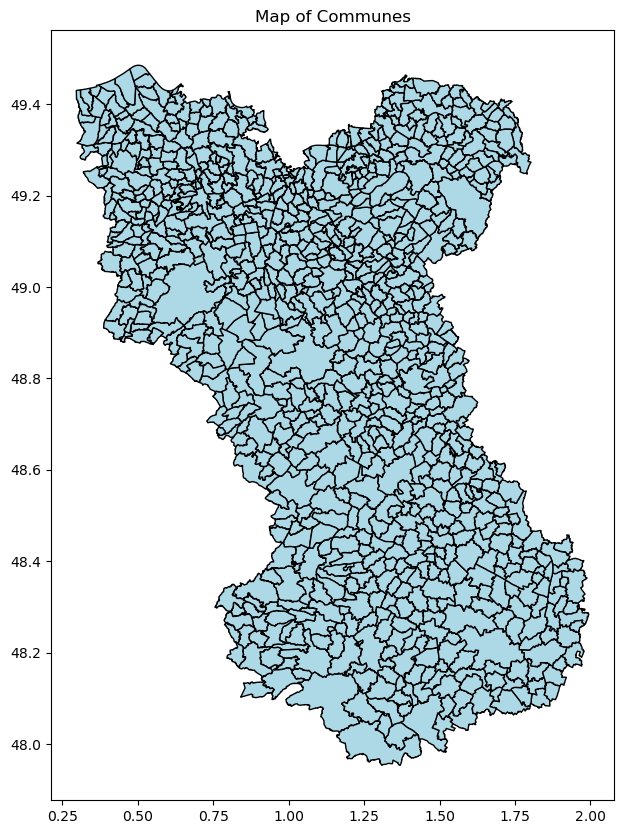

In [119]:
communes.plot(edgecolor='black', color='lightblue', figsize=(10, 10))

plt.title("Map of Communes")
plt.show()

In [120]:
communes['dep_code'] = communes['insee'].astype(str).str[:2]
# Filter only departments 27 and 28
communes = communes[communes['dep_code'].isin(['27', '28'])]

departments = communes.dissolve(by='dep_code', 
                                aggfunc={"surf_ha": "sum"})

In [121]:
communes['dep_code'] = communes['insee'].astype(str).str[:2]
communes['dep_code'] = pd.to_numeric(communes['dep_code'])
# Filter only departments 27 and 28
communes = communes[communes['dep_code'].isin([27, 28])]

departments = communes.dissolve(by='dep_code', 
                                aggfunc={"surf_ha": "sum"})

In [122]:
departments

,geometry,surf_ha
dep_code,,
27,"POLYGON ((0.44281 48.88349, 0.44297 48.88363, ...",602842.0
28,"POLYGON ((0.85313 48.12865, 0.85311 48.12866, ...",593004.0


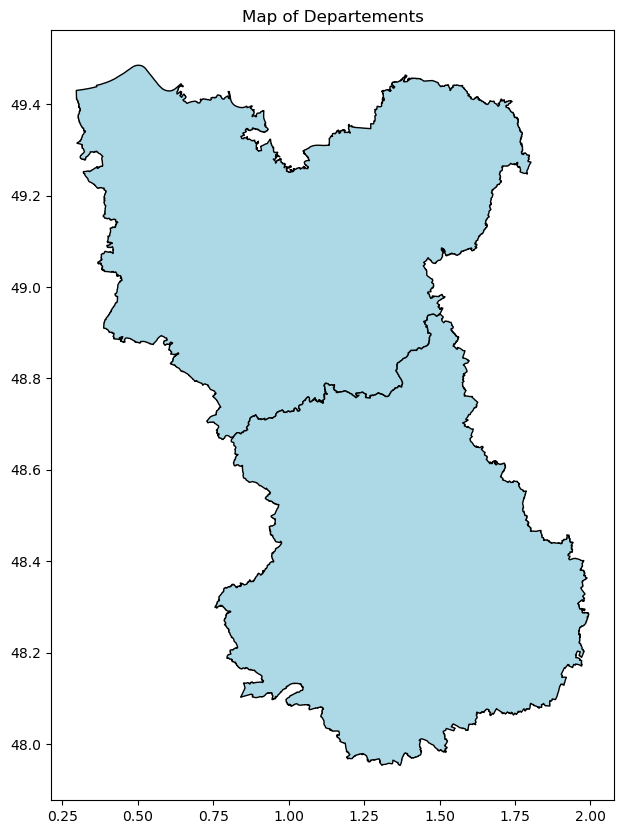

In [123]:
departments.plot(edgecolor='black', color='lightblue', figsize=(10, 10))

plt.title("Map of Departements")
plt.show()

### Agreste data

In [124]:
agreste_path = os.path.join(dir_data, 'climate', 'agreste.csv')
agreste = pd.read_csv(agreste_path)
agreste.head()

,Unnamed: 0,n1,n2,n3,n4,n5,n6,departement,dpt,variable,value,year
0,16622,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Guadeloupe,971,Production (volume),NaN,2009
1,16626,"Céréales, oléagineux, protéagineux",Céréales,Orge et escourgeon,Orge d'hiver et escourgeon,Orge d'hiver et escourgeon,Orge d'hiver et escourgeon,Guadeloupe,971,Production (volume),NaN,2009
2,16736,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Martinique,972,Production (volume),NaN,2009
3,16740,"Céréales, oléagineux, protéagineux",Céréales,Orge et escourgeon,Orge d'hiver et escourgeon,Orge d'hiver et escourgeon,Orge d'hiver et escourgeon,Martinique,972,Production (volume),NaN,2009
4,16850,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Guyane,973,Production (volume),NaN,2009


In [125]:
agreste_study = agreste[agreste['dpt'].isin(['27', '28'])]
agreste_study 

,Unnamed: 0,n1,n2,n3,n4,n5,n6,departement,dpt,variable,value,year
26,18104,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Eure-et-Loir,28,Production (volume),13788375.0,2009
27,18108,"Céréales, oléagineux, protéagineux",Céréales,Orge et escourgeon,Orge d'hiver et escourgeon,Orge d'hiver et escourgeon,Orge d'hiver et escourgeon,Eure-et-Loir,28,Production (volume),4263792.0,2009
54,19700,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Eure,27,Production (volume),13867672.0,2009
55,19704,"Céréales, oléagineux, protéagineux",Céréales,Orge et escourgeon,Orge d'hiver et escourgeon,Orge d'hiver et escourgeon,Orge d'hiver et escourgeon,Eure,27,Production (volume),2313044.0,2009
242,30392,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Eure-et-Loir,28,Production (volume),16277994.0,2002
...,...,...,...,...,...,...,...,...,...,...,...,...
12515,729937,"Céréales, oléagineux, protéagineux",Céréales,Orge et escourgeon,Orge d'hiver et escourgeon,Orge d'hiver et escourgeon,Orge d'hiver et escourgeon,Eure,27,Rendement,82.0,2019
12990,757209,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Eure-et-Loir,28,Rendement,74.0,2006
12991,757213,"Céréales, oléagineux, protéagineux",Céréales,Orge et escourgeon,Orge d'hiver et escourgeon,Orge d'hiver et escourgeon,Orge d'hiver et escourgeon,Eure-et-Loir,28,Rendement,74.0,2006
13036,759829,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Eure,27,Rendement,77.0,2006


In [126]:
agreste_study[agreste_study['year'] == 2000]

,Unnamed: 0,n1,n2,n3,n4,n5,n6,departement,dpt,variable,value,year
7808,457603,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Eure-et-Loir,28,Production (volume),15326000.0,2000
7809,457607,"Céréales, oléagineux, protéagineux",Céréales,Orge et escourgeon,Orge d'hiver et escourgeon,Orge d'hiver et escourgeon,Orge d'hiver et escourgeon,Eure-et-Loir,28,Production (volume),3187500.0,2000
8034,470463,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Eure,27,Production (volume),12464000.0,2000
8035,470467,"Céréales, oléagineux, protéagineux",Céréales,Orge et escourgeon,Orge d'hiver et escourgeon,Orge d'hiver et escourgeon,Orge d'hiver et escourgeon,Eure,27,Production (volume),1480000.0,2000
10198,597953,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Eure-et-Loir,28,Superficie développée,194000.0,2000
10199,597957,"Céréales, oléagineux, protéagineux",Céréales,Orge et escourgeon,Orge d'hiver et escourgeon,Orge d'hiver et escourgeon,Orge d'hiver et escourgeon,Eure-et-Loir,28,Superficie développée,42500.0,2000
10352,606717,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Eure,27,Superficie développée,152000.0,2000
10353,606721,"Céréales, oléagineux, protéagineux",Céréales,Orge et escourgeon,Orge d'hiver et escourgeon,Orge d'hiver et escourgeon,Orge d'hiver et escourgeon,Eure,27,Superficie développée,20000.0,2000
11142,651745,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Eure-et-Loir,28,Rendement,79.0,2000
11143,651749,"Céréales, oléagineux, protéagineux",Céréales,Orge et escourgeon,Orge d'hiver et escourgeon,Orge d'hiver et escourgeon,Orge d'hiver et escourgeon,Eure-et-Loir,28,Rendement,75.0,2000


In [127]:
# filtering on years ranging 2000-2020 (we get 1999 to cover autom 1999 which is the start of 1999-2000 season)
agreste_study = agreste_study[(agreste_study['year'] >= 1999) & (agreste_study['year'] <= 2020)]
# focusing on 'Soft winter wheat and spelt'/'Blé tendre d'hiver et épeautre'
agreste_study = agreste_study[agreste_study['n6'] == "Blé tendre d'hiver et épeautre"]
agreste_study.head()

,Unnamed: 0,n1,n2,n3,n4,n5,n6,departement,dpt,variable,value,year
26,18104,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Eure-et-Loir,28,Production (volume),13788375.0,2009
54,19700,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Eure,27,Production (volume),13867672.0,2009
242,30392,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Eure-et-Loir,28,Production (volume),16277994.0,2002
290,33148,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Eure,27,Superficie développée,152392.0,2009
306,34036,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Eure,27,Production (volume),12955692.0,2002


In [128]:
agreste_study["variable"].unique()

array(['Production (volume)', 'Superficie développée', 'Rendement'],
      dtype=object)

In [129]:
agreste_study[((agreste_study['year'] == 2009) |(agreste_study['year'] == 2010)) & (agreste_study['dpt'] == '28')]

,Unnamed: 0,n1,n2,n3,n4,n5,n6,departement,dpt,variable,value,year
26,18104,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Eure-et-Loir,28,Production (volume),13788375.0,2009
532,46912,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Eure-et-Loir,28,Superficie développée,166125.0,2009
696,56264,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Eure-et-Loir,28,Rendement,83.0,2009
1858,117275,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Eure-et-Loir,28,Production (volume),12598872.0,2010
3370,202219,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Eure-et-Loir,28,Superficie développée,161524.0,2010
5106,303467,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Eure-et-Loir,28,Rendement,78.0,2010


### ERA5 data

In [130]:
era5_path = os.path.join(dir_data, 'climate', 'ERA5_data.parquet')

era5 = pd.read_parquet(era5_path, engine="pyarrow")
era5.head()

precipitation      r_min  ssrd_mean       Tmax  \
latitude longitude date                                                         
50.0     0.00      2000-01-01       2.215229  93.606369  15.191685  10.244385   
         0.25      2000-01-01       1.814224  94.213966  13.938815  10.010773   
         0.50      2000-01-01       1.939010  95.543106  12.517365   9.940033   
         0.75      2000-01-01       1.156174  96.576569  11.264488  10.018982   
         1.00      2000-01-01       0.735961  95.136223  10.406863   9.834747   

                                   Tavg      Tmin  ws10_mean  
latitude longitude date                                       
50.0     0.00      2000-01-01  9.957440  9.599487   4.637896  
         0.25      2000-01-01  9.800465  9.500763   4.063644  
         0.50      2000-01-01  9.678520  9.181610   4.062956  
         0.75      2000-01-01  9.560416  8.507111   3.571555  
         1.00      2000-01-01  9.182507  7.840820   3.160075

In [131]:
era5 = era5.reset_index()

# Create Point geometries from lat/lon as shown for Airbnb Bordeaux case study

gdf_era5 = gpd.GeoDataFrame(
    era5,
    geometry=gpd.points_from_xy(era5['longitude'], era5['latitude']),
    crs='EPSG:4326'
)


Spatial join department / ERA5

In [132]:
departments.index

Index([27, 28], dtype='int64', name='dep_code')

In [133]:
dep_meteo= gpd.sjoin(gdf_era5, departments, how="inner", predicate="intersects")

dep_meteo.head()

,latitude,longitude,date,precipitation,r_min,ssrd_mean,Tmax,Tavg,Tmin,ws10_mean,geometry,dep_code,surf_ha
35,49.25,0.50,2000-01-01,0.309356,97.214012,7.206346,10.097961,8.840594,7.483826,2.552514,POINT (0.5 49.25),27,602842.0
36,49.25,0.75,2000-01-01,0.152569,95.971680,6.572129,10.091370,8.782670,7.210724,2.507713,POINT (0.75 49.25),27,602842.0
37,49.25,1.00,2000-01-01,0.195235,95.054848,6.176875,10.027222,8.672790,6.937653,2.348884,POINT (1 49.25),27,602842.0
38,49.25,1.25,2000-01-01,0.306156,94.078339,6.125319,10.007477,8.599995,6.700745,2.116743,POINT (1.25 49.25),27,602842.0
39,49.25,1.50,2000-01-01,0.234690,92.987907,6.364274,9.823212,8.392085,6.496735,2.094419,POINT (1.5 49.25),27,602842.0


/var/folders/qb/99v_gzds7j7725jspcz_ch9w0000gn/T/ipykernel_90434/630669229.py:7: UserWarning:

Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler



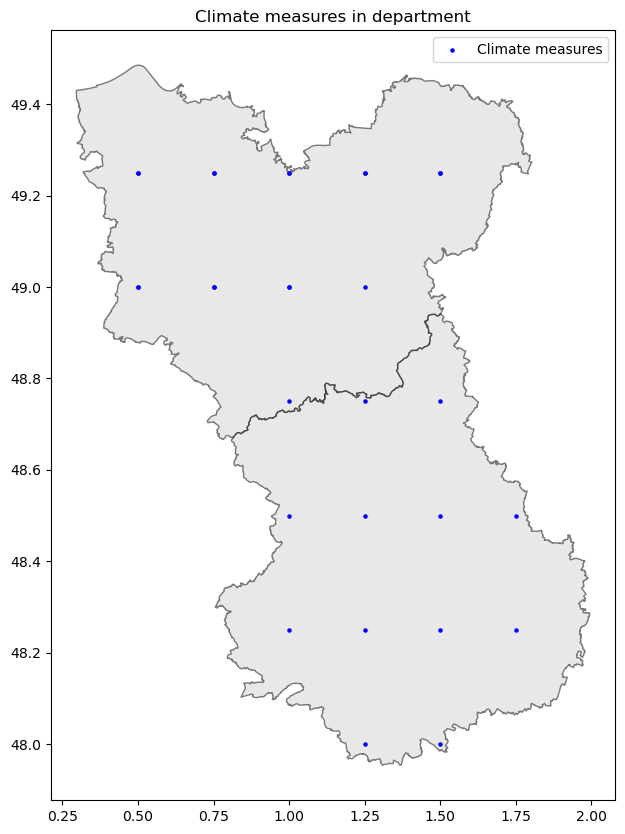

In [134]:
fig, ax = plt.subplots(figsize=(10, 10))

departments.plot(ax=ax, color="lightgrey", edgecolor="black", alpha=0.5, label="Departments")

dep_meteo.head(30).plot(ax=ax, color="blue", markersize=5, label="Climate measures")

plt.legend()
plt.title("Climate measures in department")
plt.show()

### EDA

In [135]:
dep_meteo['year'] = dep_meteo['date'].dt.year

In [136]:
(dep_meteo
    .drop(columns=["geometry"])  
    .groupby(["latitude", "longitude", "year"])
    .mean()  
    .reset_index())

,latitude,longitude,year,date,precipitation,r_min,ssrd_mean,Tmax,Tavg,Tmin,ws10_mean,dep_code,surf_ha
0,48.00,1.25,2000,2000-07-01 12:00:00,2.461066,63.967293,130.607071,15.329027,11.603306,7.809484,3.879995,28.0,593004.0
1,48.00,1.25,2001,2001-07-02 00:00:00,2.477304,63.340229,133.828323,14.990272,11.268507,7.440420,4.051219,28.0,593004.0
2,48.00,1.25,2002,2002-07-02 00:00:00,2.389293,62.136921,134.378265,15.705446,11.742064,7.748419,4.177293,28.0,593004.0
3,48.00,1.25,2003,2003-07-02 00:00:00,1.661479,56.311161,149.853409,16.575037,12.072912,7.507010,3.705889,28.0,593004.0
4,48.00,1.25,2004,2004-07-01 12:00:00,1.798413,59.854603,142.723038,15.268896,11.270201,7.208337,3.927081,28.0,593004.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
457,49.25,1.50,2016,2016-07-01 12:00:00,2.036695,62.865810,130.108795,14.702156,11.027387,7.377025,3.520861,27.0,602842.0
458,49.25,1.50,2017,2017-07-02 00:00:00,1.939118,62.482174,130.326569,15.363644,11.550384,7.609156,3.475546,27.0,602842.0
459,49.25,1.50,2018,2018-07-02 00:00:00,2.135761,60.456463,138.116486,15.874730,11.934723,7.959451,3.604194,27.0,602842.0
460,49.25,1.50,2019,2019-07-02 00:00:00,2.358436,59.880077,140.919922,15.555495,11.656857,7.594262,3.735831,27.0,602842.0


In [137]:
moy_point = (
    dep_meteo
    .drop(columns=["geometry"])  
    .groupby(["latitude", "longitude", "year"])
    .mean()  
    .reset_index()  
)

moy_point.head()

,latitude,longitude,year,date,precipitation,r_min,ssrd_mean,Tmax,Tavg,Tmin,ws10_mean,dep_code,surf_ha
0,48.0,1.25,2000,2000-07-01 12:00:00,2.461066,63.967293,130.607071,15.329027,11.603306,7.809484,3.879995,28.0,593004.0
1,48.0,1.25,2001,2001-07-02 00:00:00,2.477304,63.340229,133.828323,14.990272,11.268507,7.440420,4.051219,28.0,593004.0
2,48.0,1.25,2002,2002-07-02 00:00:00,2.389293,62.136921,134.378265,15.705446,11.742064,7.748419,4.177293,28.0,593004.0
3,48.0,1.25,2003,2003-07-02 00:00:00,1.661479,56.311161,149.853409,16.575037,12.072912,7.507010,3.705889,28.0,593004.0
4,48.0,1.25,2004,2004-07-01 12:00:00,1.798413,59.854603,142.723038,15.268896,11.270201,7.208337,3.927081,28.0,593004.0


In [138]:
moy_dep = moy_point.groupby(['year', 'dep_code']).mean()
moy_dep.reset_index(inplace=True)
moy_dep.head()

,year,dep_code,latitude,longitude,date,precipitation,r_min,ssrd_mean,Tmax,Tavg,Tmin,ws10_mean,surf_ha
0,2000,27.0,49.100,0.950,2000-07-01 12:00:00,2.646621,65.926888,124.809875,14.563917,11.132341,7.726399,3.892630,602842.0
1,2000,28.0,48.375,1.375,2000-07-01 12:00:00,2.403574,64.455490,128.615112,14.996593,11.358604,7.665322,3.928379,593004.0
2,2001,27.0,49.100,0.950,2001-07-02 00:00:00,2.547833,64.441696,131.301422,14.526972,10.977462,7.344859,3.885483,602842.0
3,2001,28.0,48.375,1.375,2001-07-02 00:00:00,2.398058,63.513073,132.847305,14.764392,11.100545,7.326052,4.054427,593004.0
4,2002,27.0,49.100,0.950,2002-07-02 00:00:00,2.376900,64.324417,128.981354,14.946440,11.262922,7.565473,4.049709,602842.0


In [139]:
agreste_study['dpt']

26       28
54       27
242      28
290      27
306      27
         ..
12378    28
12458    27
12514    27
12990    28
13036    27
Name: dpt, Length: 126, dtype: object

In [140]:
agreste_study['dep_code'] = agreste_study['dpt'].astype('float64')
# keeping only Production
agreste_study = agreste_study[agreste_study['variable'] == 'Rendement']

In [141]:
merged_df = pd.merge(moy_dep, agreste_study, on=["dep_code", "year"], how="inner") 
merged_df.head() 

,year,dep_code,latitude,longitude,date,precipitation,r_min,ssrd_mean,Tmax,Tavg,...,n1,n2,n3,n4,n5,n6,departement,dpt,variable,value
0,2000,27.0,49.100,0.950,2000-07-01 12:00:00,2.646621,65.926888,124.809875,14.563917,11.132341,...,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Eure,27,Rendement,82.0
1,2000,28.0,48.375,1.375,2000-07-01 12:00:00,2.403574,64.455490,128.615112,14.996593,11.358604,...,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Eure-et-Loir,28,Rendement,79.0
2,2001,27.0,49.100,0.950,2001-07-02 00:00:00,2.547833,64.441696,131.301422,14.526972,10.977462,...,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Eure,27,Rendement,73.0
3,2001,28.0,48.375,1.375,2001-07-02 00:00:00,2.398058,63.513073,132.847305,14.764392,11.100545,...,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Eure-et-Loir,28,Rendement,71.0
4,2002,27.0,49.100,0.950,2002-07-02 00:00:00,2.376900,64.324417,128.981354,14.946440,11.262922,...,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,Blé tendre d'hiver et épeautre,Eure,27,Rendement,87.0


In [142]:
merged_df = merged_df.rename(columns={"value": "crop_yield"})
merged_df = merged_df.drop(columns=['n6', 'departement','variable'])
merged_df.head()

,year,dep_code,latitude,longitude,date,precipitation,r_min,ssrd_mean,Tmax,Tavg,...,ws10_mean,surf_ha,Unnamed: 0,n1,n2,n3,n4,n5,dpt,crop_yield
0,2000,27.0,49.100,0.950,2000-07-01 12:00:00,2.646621,65.926888,124.809875,14.563917,11.132341,...,3.892630,602842.0,669109,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,27,82.0
1,2000,28.0,48.375,1.375,2000-07-01 12:00:00,2.403574,64.455490,128.615112,14.996593,11.358604,...,3.928379,593004.0,651745,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,28,79.0
2,2001,27.0,49.100,0.950,2001-07-02 00:00:00,2.547833,64.441696,131.301422,14.526972,10.977462,...,3.885483,602842.0,619141,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,27,73.0
3,2001,28.0,48.375,1.375,2001-07-02 00:00:00,2.398058,63.513073,132.847305,14.764392,11.100545,...,4.054427,593004.0,596041,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,28,71.0
4,2002,27.0,49.100,0.950,2002-07-02 00:00:00,2.376900,64.324417,128.981354,14.946440,11.262922,...,4.049709,602842.0,179375,"Céréales, oléagineux, protéagineux",Céréales,Blé,Blé tendre et épeautre,Blé tendre d'hiver et épeautre,27,87.0


First, we will calculate, for each department, the year with the highest production, the lowest production, and the median production.

In [143]:
# Function to compute statistics by department
def stats_by_department(group):
    # Highest crop_yield
    year_max = group.loc[group['crop_yield'].idxmax(), 'year']
    value_max = group['crop_yield'].max()
    
    # Lowest crop_yield
    year_min = group.loc[group['crop_yield'].idxmin(), 'year']
    value_min = group['crop_yield'].min()
    
    # Median crop_yield
    median_value = group['crop_yield'].median()
    year_median = group.loc[(group['crop_yield'] - median_value).abs().idxmin(), 'year']
    
    return pd.Series({
        'Max Year': year_max,
        'Max Crop Yield': value_max,
        'Min Year': year_min,
        'Min Crop Yield': value_min,
        'Median Crop Yield': median_value,
        'Median Year': year_median
    })

# Apply the function to each department
results = merged_df.groupby('dpt').apply(stats_by_department, include_groups=False)

print(results)


     Max Year  Max Crop Yield  Min Year  Min Crop Yield  Median Crop Yield  \
dpt                                                                          
27     2015.0            93.0    2016.0            67.0               84.0   
28     2002.0            86.0    2016.0            54.3               79.0   

     Median Year  
dpt               
27        2010.0  
28        2000.0  


## Eure

We now explore the climate data for these Good (2015) - Median (2010) - Bad (2016) Crop Yield year for the Eure department

In [144]:
moy_date = (
    dep_meteo
    .drop(columns=["geometry"])  
    .groupby(["date", "dep_code"])
    .mean()  
    .reset_index()  
)

moy_date.head()

,date,dep_code,latitude,longitude,precipitation,r_min,ssrd_mean,Tmax,Tavg,Tmin,ws10_mean,surf_ha,year
0,2000-01-01,27,49.100,0.950,0.205901,95.262085,6.722624,9.730764,8.539525,6.940433,2.389997,602842.0,2000.0
1,2000-01-01,28,48.375,1.375,0.312910,91.057953,14.463367,9.387260,8.121772,6.574338,2.214361,593004.0,2000.0
2,2000-01-02,27,49.100,0.950,0.539182,90.791580,19.342951,10.063907,8.587156,7.758401,2.723717,602842.0,2000.0
3,2000-01-02,28,48.375,1.375,0.399113,97.790428,12.374081,9.113892,7.871986,6.716093,2.531683,593004.0,2000.0
4,2000-01-03,27,49.100,0.950,0.155242,83.516884,18.069616,9.232122,8.062432,7.203000,5.267795,602842.0,2000.0


##### Precipitations

In [145]:
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'notebook' 

# Ensure date is in the correct datetime format
moy_date['date'] = pd.to_datetime(moy_date['date'])

# Create year and month columns
moy_date['Year'] = moy_date['date'].dt.year
moy_date['Month'] = moy_date['date'].dt.month

# Keep only department 27
moy_date_filtered = moy_date[moy_date['dep_code'] == 27]

# Group by year and month to calculate total (or mean) monthly precipitation
monthly_precip = (
    moy_date_filtered
    .groupby(['Year', 'Month'])['precipitation']
    .sum()
    .reset_index()
)

# Select years of interest
selected_years = [2010, 2015, 2016]
filtered_precip = monthly_precip[monthly_precip['Year'].isin(selected_years)]

# Pivot data for easier plotting
precip_pivot = filtered_precip.pivot(index='Month', columns='Year', values='precipitation')

# Define colors by year
colors = {
    2010: 'orange',
    2015: 'green',
    2016: 'red'
}

# Define legend labels
legends = {
    2010: '2010 - Median year',
    2015: '2015 - Good year',
    2016: '2016 - Bad year'
}

# Create Plotly figure
fig = go.Figure()

for year in selected_years:
    fig.add_trace(go.Scatter(
        x=precip_pivot.index,
        y=precip_pivot[year],
        mode='lines+markers',
        name=legends[year],
        line=dict(color=colors[year])
    ))

fig.update_layout(
    title="Monthly Precipitation Trends in Eure (Department 27)",
    xaxis=dict(
        title="Month",
        tickmode='array',
        tickvals=list(range(1, 13)),
        ticktext=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                  'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    ),
    yaxis=dict(title="Precipitation (mm)"),
    legend_title="Years",
    template="plotly_white"
)

fig.show()

In [146]:
# Ensure date is in the correct datetime format
moy_date['date'] = pd.to_datetime(moy_date['date'])

# Create year and month columns
moy_date['Year'] = moy_date['date'].dt.year
moy_date['Month'] = moy_date['date'].dt.month

moy_date['HarvestYear']=moy_date['date'].dt.year + (moy_date['date'].dt.month >= 9).astype(int)

# Keep only department 27
moy_date_filtered = moy_date[moy_date['dep_code'] == 27]

# Group by year and month to calculate total (or mean) monthly precipitation
monthly_precip = (
    moy_date_filtered
    .groupby(['HarvestYear', 'Month'])['precipitation']
    .sum()
    .reset_index()
)

# Select years of interest
selected_years = [2010, 2015, 2016]
filtered_precip = monthly_precip[monthly_precip['HarvestYear'].isin(selected_years)]

# Pivot data for easier plotting
precip_pivot = filtered_precip.pivot(index='Month', columns='HarvestYear', values='precipitation')

# LO: Reorder From September N-1 to August N the true Soft wheat season
seasonal_order = [9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8]
precip_pivot = precip_pivot.loc[seasonal_order]

month_labels = ['Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb',  
                'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug']
precip_pivot.index = month_labels

# Define colors by year
colors = {
    2010: 'orange',
    2015: 'green',
    2016: 'red'
}

# Define legend labels
legends = {
    2010: '2010 - Median year',
    2015: '2015 - Good year',
    2016: '2016 - Bad year'
}

# Create Plotly figure
fig = go.Figure()

for year in selected_years:
    fig.add_trace(go.Scatter(
        x=precip_pivot.index,
        y=precip_pivot[year],
        mode='lines+markers',
        name=legends[year],
        line=dict(color=colors[year])
    ))

fig.update_layout(
    title="Monthly Precipitation Trends in Eure (Department 27)",
    xaxis=dict(
        type='category',
        title="Month",
    ),
    yaxis=dict(title="Precipitation (mm)"),
    legend_title="Years",
    template="plotly_white"
)

fig.show()

#### Minimum Relative Humidity

In [147]:
# Keep only department 27
moy_date_filtered = moy_date[moy_date['dep_code'] == 27]

# Group by year and month to calculate mean monthly minimum relative humidity
monthly_humidity = (
    moy_date_filtered
    .groupby(['Year', 'Month'])['r_min']
    .mean()
    .reset_index()
)

# Filter for selected years
selected_years = [2010, 2015, 2016]
filtered_humidity = monthly_humidity[monthly_humidity['Year'].isin(selected_years)]

# Pivot data for easier plotting
humidity_pivot = filtered_humidity.pivot(index='Month', columns='Year', values='r_min')

# Custom colors
colors = {
    2010: 'orange',
    2015: 'green',
    2016: 'red'
}

# Custom legend labels
legends = {
    2010: '2010 - Median year',
    2015: '2015 - Good year',
    2016: '2016 - Bad year'
}

# Create Plotly figure
fig = go.Figure()

for year in selected_years:
    fig.add_trace(go.Scatter(
        x=humidity_pivot.index,
        y=humidity_pivot[year],
        mode='lines+markers',
        name=legends[year],
        line=dict(color=colors[year])
    ))

fig.update_layout(
    title="Monthly Minimum Relative Humidity in Eure (Department 27)",
    xaxis=dict(
        title="Month",
        tickmode='array',
        tickvals=list(range(1, 13)),
        ticktext=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                  'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    ),
    yaxis=dict(title="Minimum Relative Humidity (%)"),
    legend_title="Years",
    template="plotly_white"
)

fig.show()


#### Solar Radiation

In [148]:
# Filter data for department code 27
moy_date_filtered = moy_date[moy_date['dep_code'] == 27]

# Group by year and month to calculate mean monthly solar radiation
monthly_radiation = (
    moy_date_filtered
    .groupby(['Year', 'Month'])['ssrd_mean']
    .mean()
    .reset_index()
)

# Filter for selected years
selected_years = [2010, 2015, 2016]
filtered_radiation = monthly_radiation[monthly_radiation['Year'].isin(selected_years)]

# Pivot data for easier plotting
radiation_pivot = filtered_radiation.pivot(index='Month', columns='Year', values='ssrd_mean')

# Custom colors
colors = {
    2010: 'orange',
    2015: 'green',
    2016: 'red'
}

# Custom legend labels
legends = {
    2010: '2010 - Median year',
    2015: '2015 - Good year',
    2016: '2016 - Bad year'
}

# Create Plotly figure
fig = go.Figure()

# Add a trace for each year with custom colors and labels
for year in selected_years:
    fig.add_trace(go.Scatter(
        x=radiation_pivot.index,
        y=radiation_pivot[year],
        mode='lines+markers',
        name=legends[year],
        line=dict(color=colors[year])
    ))

# Customize layout
fig.update_layout(
    title="Monthly Mean Solar Radiation in Eure (Department 27)",
    xaxis=dict(
        title="Month",
        tickmode='array',
        tickvals=list(range(1, 13)),
        ticktext=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                  'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    ),
    yaxis=dict(title="Mean Solar Radiation (W/m²)"),
    legend_title="Years",
    template="plotly_white"
)

# Show figure
fig.show()


## Eure-et-Loir

We now explore the climate data for these Good (2002) - Median (2000) - Bad (2016) Crop Yield year for the Eure department

##### Precipitations

In [149]:
# Keep only department 28
moy_date_filtered = moy_date[moy_date['dep_code'] == 28]

# Group by year and month to calculate total (or mean) monthly precipitation
monthly_precip = (
    moy_date_filtered
    .groupby(['Year', 'Month'])['precipitation']
    .sum()
    .reset_index()
)

# Select years of interest
selected_years = [2002, 2000, 2016]
filtered_precip = monthly_precip[monthly_precip['Year'].isin(selected_years)]

# Pivot data for easier plotting
precip_pivot = filtered_precip.pivot(index='Month', columns='Year', values='precipitation')

# Define colors by year
colors = {
    2000: 'orange',
    2002: 'green',
    2016: 'red'
}

# Define legend labels
legends = {
    2000: '2000 - Median year',
    2002: '2002 - Good year',
    2016: '2016 - Bad year'
}

# Create Plotly figure
fig = go.Figure()

for year in selected_years:
    fig.add_trace(go.Scatter(
        x=precip_pivot.index,
        y=precip_pivot[year],
        mode='lines+markers',
        name=legends[year],
        line=dict(color=colors[year])
    ))

fig.update_layout(
    title="Monthly Precipitation Trends in Eure-et-Loir (Department 28)",
    xaxis=dict(
        title="Month",
        tickmode='array',
        tickvals=list(range(1, 13)),
        ticktext=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                  'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    ),
    yaxis=dict(title="Precipitation (mm)"),
    legend_title="Years",
    template="plotly_white"
)

fig.show()

In [150]:
# Ensure date is in the correct datetime format
moy_date['date'] = pd.to_datetime(moy_date['date'])

# Create year and month columns
moy_date['Year'] = moy_date['date'].dt.year
moy_date['Month'] = moy_date['date'].dt.month

moy_date['HarvestYear']=moy_date['date'].dt.year + (moy_date['date'].dt.month >= 9).astype(int)

# Keep only department 27
moy_date_filtered = moy_date[moy_date['dep_code'] == 28]

# Group by year and month to calculate total (or mean) monthly precipitation
monthly_precip = (
    moy_date_filtered
    .groupby(['HarvestYear', 'Month'])['precipitation']
    .sum()
    .reset_index()
)

# Select years of interest
selected_years = [2002, 2000, 2016]
filtered_precip = monthly_precip[monthly_precip['HarvestYear'].isin(selected_years)]

# Pivot data for easier plotting
precip_pivot = filtered_precip.pivot(index='Month', columns='HarvestYear', values='precipitation')

# LO: Reorder From September N-1 to August N the true Soft wheat season
seasonal_order = [9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8]
precip_pivot = precip_pivot.loc[seasonal_order]

month_labels = ['Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb',  
                'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug']
precip_pivot.index = month_labels

# Define colors by year
colors = {
    2000: 'orange',
    2002: 'green',
    2016: 'red'
}

# Define legend labels
legends = {
    2000: '2000 - Median year',
    2002: '2002 - Good year',
    2016: '2016 - Bad year'
}

# Create Plotly figure
fig = go.Figure()

for year in selected_years:
    fig.add_trace(go.Scatter(
        x=precip_pivot.index,
        y=precip_pivot[year],
        mode='lines+markers',
        name=legends[year],
        line=dict(color=colors[year])
    ))

fig.update_layout(
    title="Monthly Precipitation Trends in Eure-et-Loir (Department 28)",
    xaxis=dict(
        type='category',
        title="Month",
    ),
    yaxis=dict(title="Precipitation (mm)"),
    legend_title="Years",
    template="plotly_white"
)

fig.show()

#### Minimum Relative Humidity

In [151]:
# Keep only department 27
moy_date_filtered = moy_date[moy_date['dep_code'] == 28]

# Group by year and month to calculate mean monthly minimum relative humidity
monthly_humidity = (
    moy_date_filtered
    .groupby(['Year', 'Month'])['r_min']
    .mean()
    .reset_index()
)

# Filter for selected years
selected_years = [2002, 2000, 2016]
filtered_humidity = monthly_humidity[monthly_humidity['Year'].isin(selected_years)]

# Pivot data for easier plotting
humidity_pivot = filtered_humidity.pivot(index='Month', columns='Year', values='r_min')

# Custom colors
colors = {
    2000: 'orange',
    2002: 'green',
    2016: 'red'
}

# Custom legend labels
legends = {
    2000: '2000 - Median year',
    2002: '2002 - Good year',
    2016: '2016 - Bad year'
}

# Create Plotly figure
fig = go.Figure()

for year in selected_years:
    fig.add_trace(go.Scatter(
        x=humidity_pivot.index,
        y=humidity_pivot[year],
        mode='lines+markers',
        name=legends[year],
        line=dict(color=colors[year])
    ))

fig.update_layout(
    title="Monthly Minimum Relative Humidity in Eure-et-Loir (Department 28)",
    xaxis=dict(
        title="Month",
        tickmode='array',
        tickvals=list(range(1, 13)),
        ticktext=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                  'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    ),
    yaxis=dict(title="Minimum Relative Humidity (%)"),
    legend_title="Years",
    template="plotly_white"
)

fig.show()


#### Solar Radiation

In [152]:
# Filter data for department code 27
moy_date_filtered = moy_date[moy_date['dep_code'] == 28]

# Group by year and month to calculate mean monthly solar radiation
monthly_radiation = (
    moy_date_filtered
    .groupby(['Year', 'Month'])['ssrd_mean']
    .mean()
    .reset_index()
)

# Filter for selected years
selected_years = [2002, 2000, 2016]
filtered_radiation = monthly_radiation[monthly_radiation['Year'].isin(selected_years)]

# Pivot data for easier plotting
radiation_pivot = filtered_radiation.pivot(index='Month', columns='Year', values='ssrd_mean')

# Custom colors
colors = {
    2000: 'orange',
    2002: 'green',
    2016: 'red'
}

# Custom legend labels
legends = {
    2000: '2000 - Median year',
    2002: '2002 - Good year',
    2016: '2016 - Bad year'
}

# Create Plotly figure
fig = go.Figure()

# Add a trace for each year with custom colors and labels
for year in selected_years:
    fig.add_trace(go.Scatter(
        x=radiation_pivot.index,
        y=radiation_pivot[year],
        mode='lines+markers',
        name=legends[year],
        line=dict(color=colors[year])
    ))

# Customize layout
fig.update_layout(
    title="Monthly Mean Solar Radiation in Eure-et-Loir (Department 28)",
    xaxis=dict(
        title="Month",
        tickmode='array',
        tickvals=list(range(1, 13)),
        ticktext=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                  'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    ),
    yaxis=dict(title="Mean Solar Radiation (W/m²)"),
    legend_title="Years",
    template="plotly_white"
)

# Show figure
fig.show()


The code and notebook structure above closely mimic an actual data analysis submitted by a candidate during a real-world case interview (with time constraints and a beginner comfort level with Python). The baseline was quite solid.

While I have slightly cleansed the code for readability, I kept it as is to show something realistic, still there is room for improvement:

- Code Refactoring & Modularisation: Instead of repeating plotting code blocks, you could refactor and bundle the logic into a single, reusable function with dynamic parameters (e.g., plot_crop_yield(df, department, metric)).

- Better visualisations: look at how agricultural institutes like Arvalis communicate data. When explaining why 2016 was a historically poor year for soft winter wheat in France, they published comparative visualisations overlaying that specific "bad" year directly against the historical distribution of past years.

As a next step try to reproduce those Arvalis-style distribution plots below using this dataset or propose better metrics/visualisations:

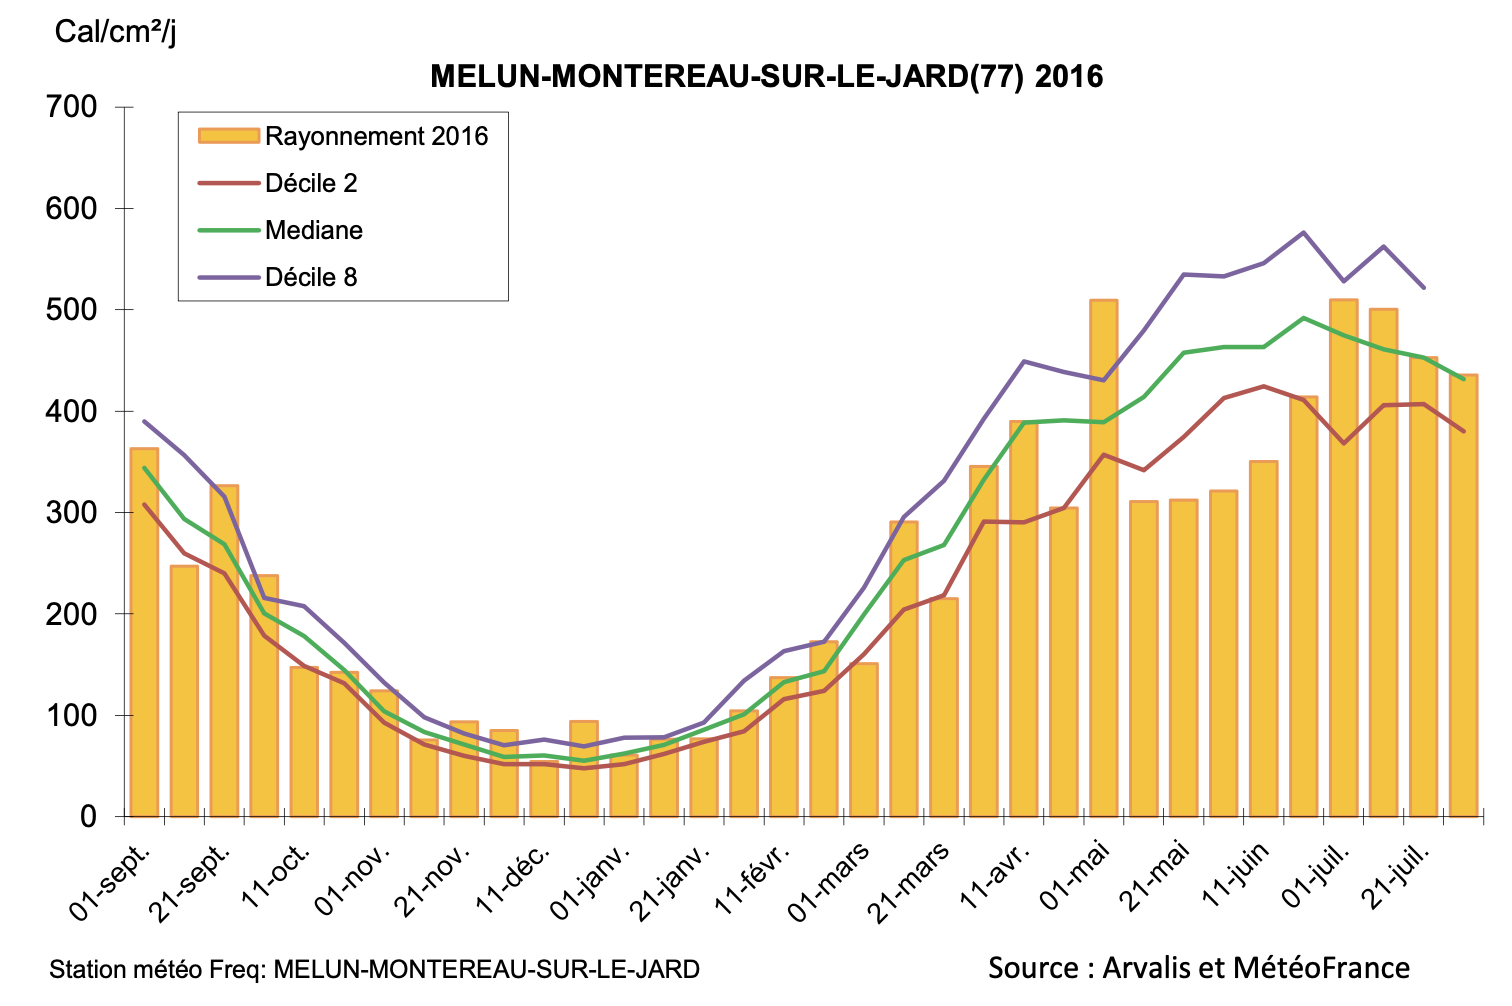

In [153]:
#| code-fold: true
img_colab('sun_agreste.png')

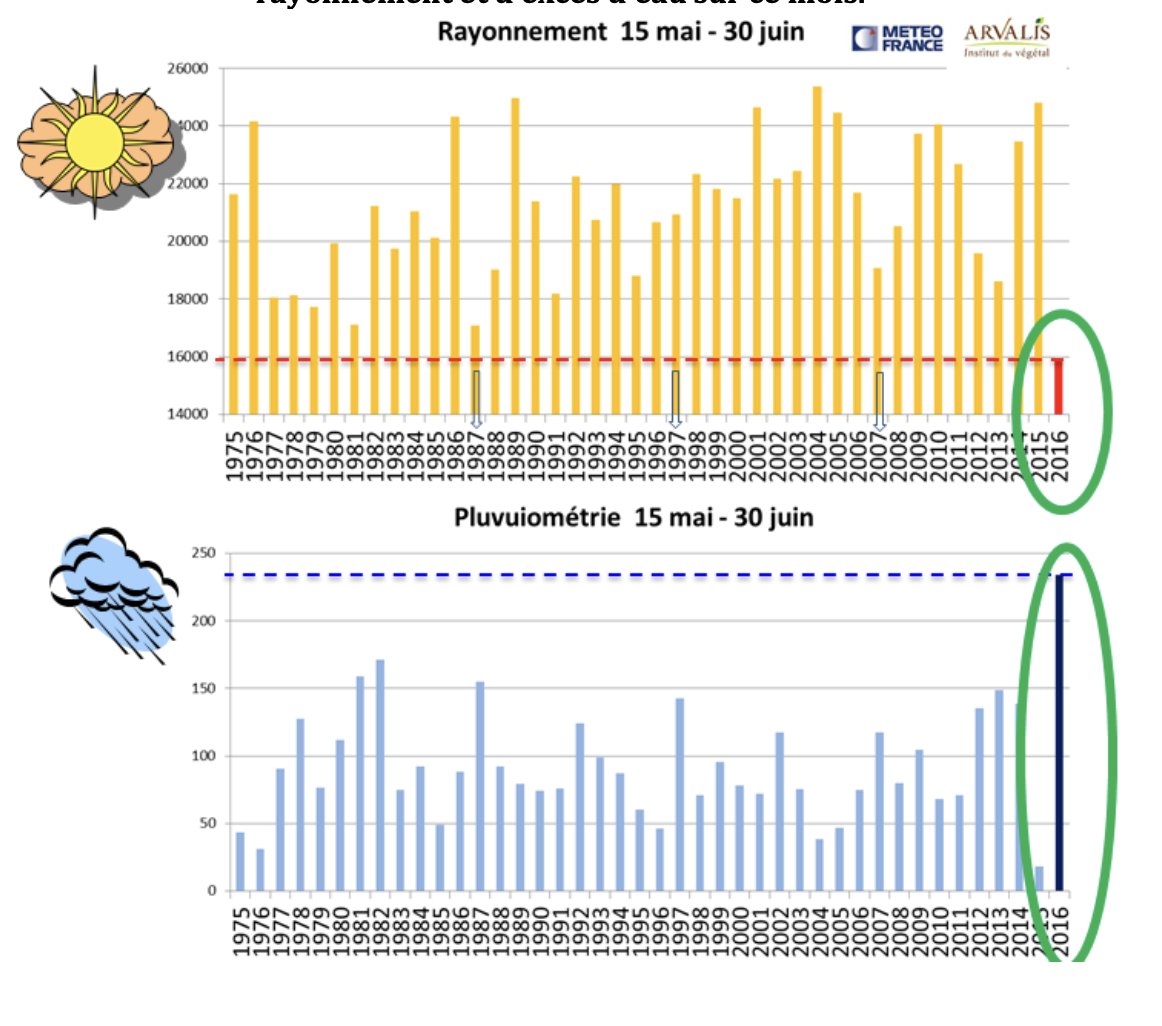

In [154]:
img_colab("sun_rain_2016.png")